Preparação dos dados

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
n_registros = 120

datas = pd.date_range(
    start='2024-01-01',
    periods=n_registros,
    freq='D'
)

categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)

df['valor_venda'] = (
    df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)
).round(2)

# Preparando a data para os agrupamentos
df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data')

# Faturamento total por mês
faturamento_mensal = df['valor_venda'].resample('ME').sum()

# Quantidade total de itens vendidos por mês
quantidade_mensal = df['quantidade'].resample('ME').sum()

# Quantidade média de itens por venda, por mês
media_itens_mensal = df['quantidade'].resample('ME').mean()

Gráfico de linha: faturamento mensal

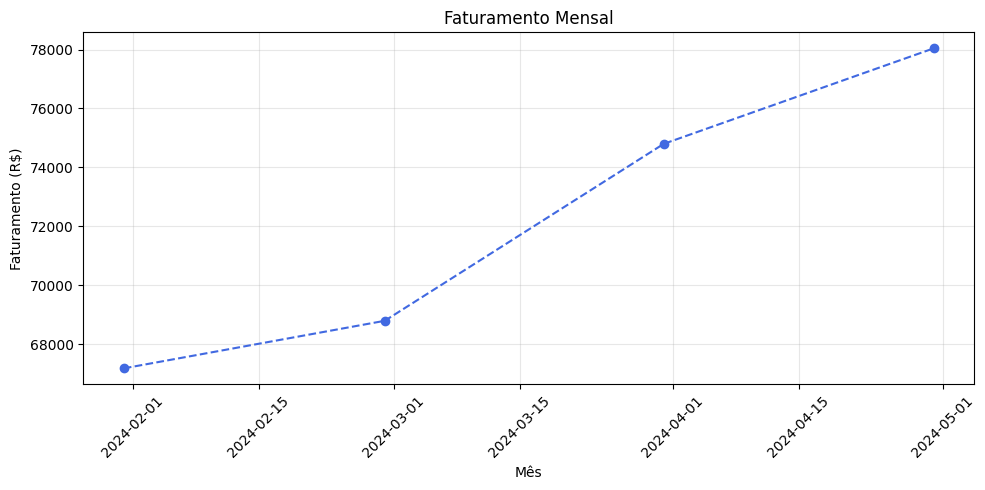

In [2]:
plt.figure(figsize=(10, 5))

plt.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

plt.title('Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Gráfico de barras: vendas por categoria

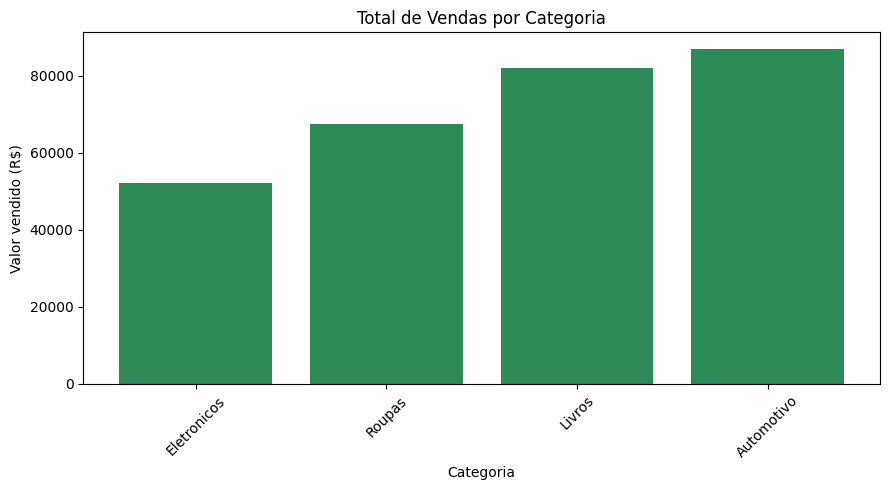

In [3]:
vendas_categoria = (
    df.groupby('categoria')['valor_venda']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

plt.bar(
    vendas_categoria.index,
    vendas_categoria.values,
    color='seagreen'
)

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor vendido (R$)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Histograma: distribuição dos valores das vendas

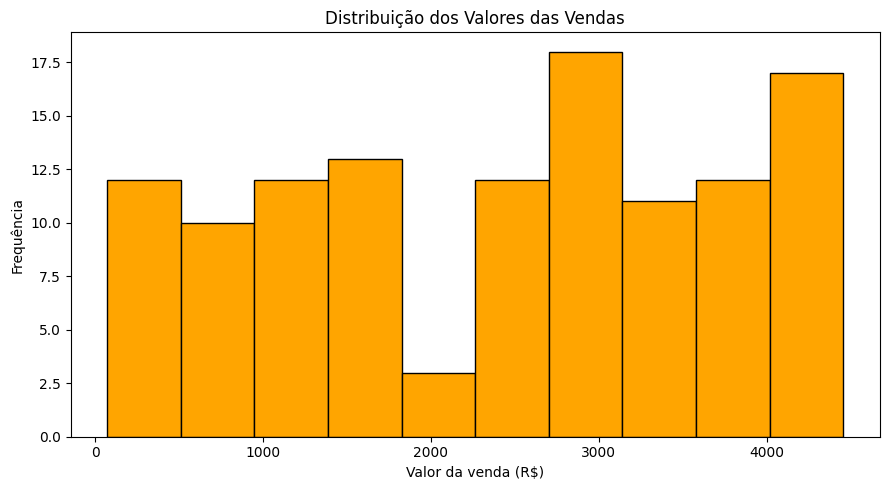

In [4]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['valor'],
    bins=10,
    edgecolor='black',
    color='orange'
)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da venda (R$)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

Dois gráficos, um em cima e outro embaixo, com os mesmos meses e com o faturamento e quantidade de itens vendidos por mês

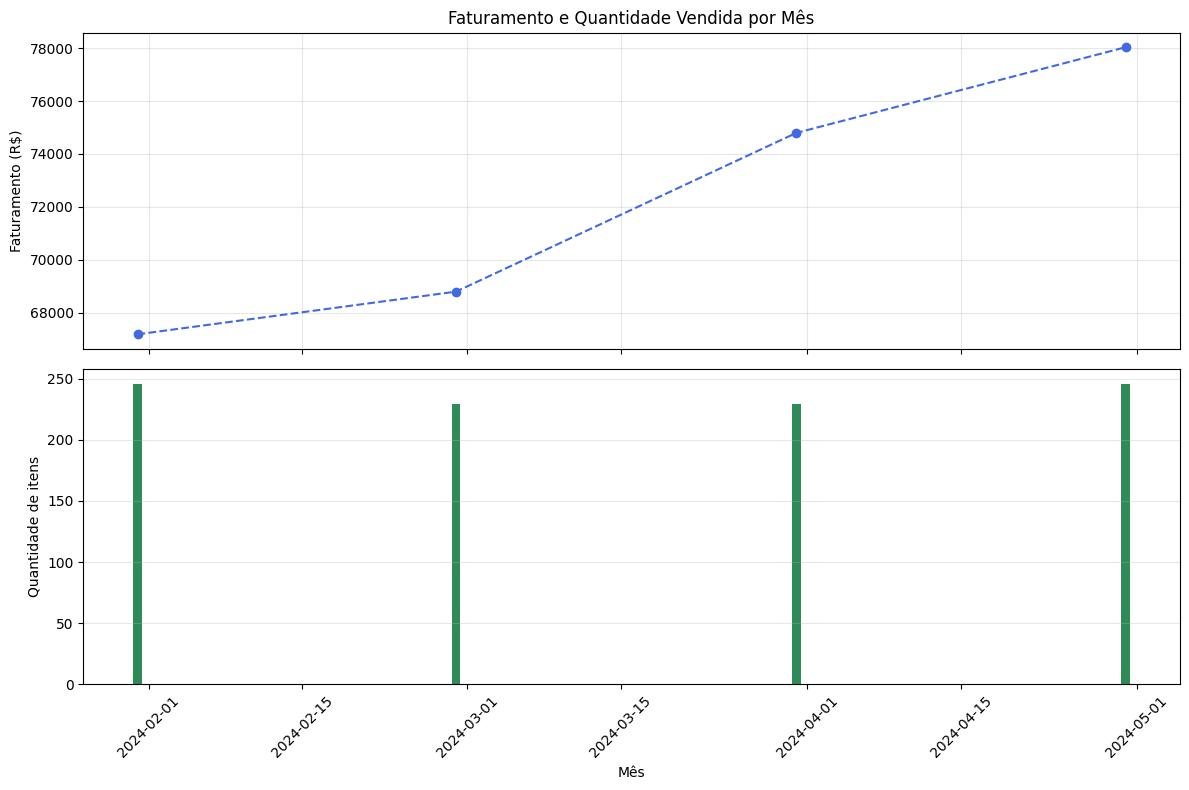

In [5]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

# Gráfico superior: faturamento mensal
ax1.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

ax1.set_title('Faturamento e Quantidade Vendida por Mês')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, alpha=0.3)

# Gráfico inferior: quantidade de itens vendidos
ax2.bar(
    quantidade_mensal.index,
    quantidade_mensal.values,
    color='seagreen'
)

ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de itens')
ax2.grid(True, axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Gráfico com dois eixos Y usando twinx()

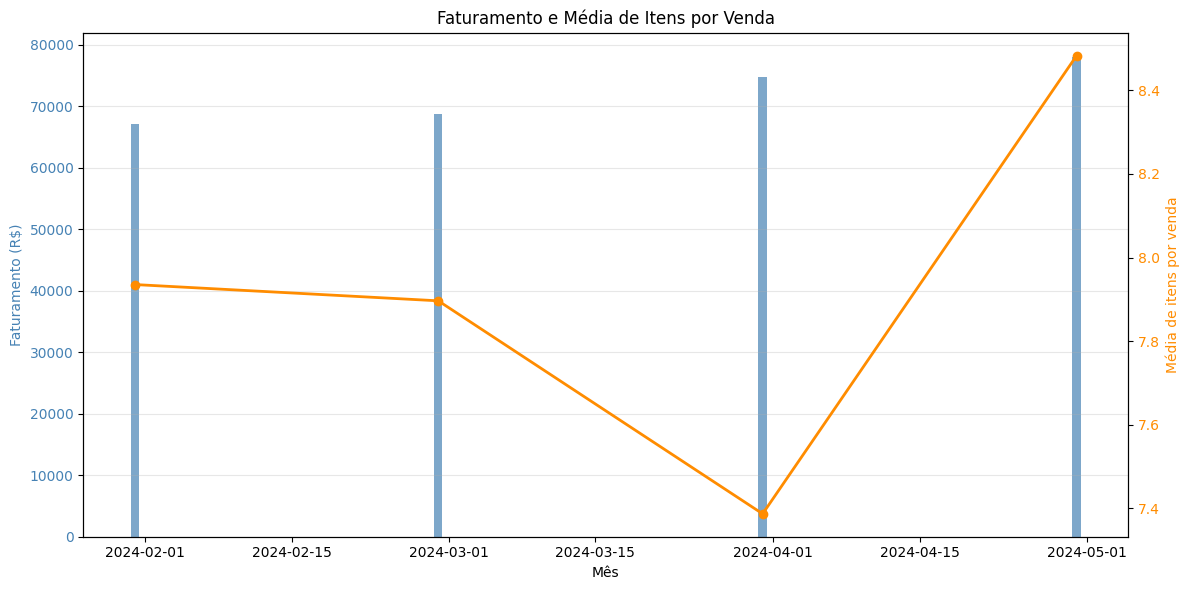

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y primário: faturamento
ax1.bar(
    faturamento_mensal.index,
    faturamento_mensal.values,
    color='steelblue',
    alpha=0.7,
    label='Faturamento'
)

ax1.set_xlabel('Mês')
ax1.set_ylabel('Faturamento (R$)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, axis='y', alpha=0.3)

# Eixo Y secundário: quantidade média
ax2 = ax1.twinx()

ax2.plot(
    media_itens_mensal.index,
    media_itens_mensal.values,
    marker='o',
    color='darkorange',
    linewidth=2,
    label='Média de itens por venda'
)

ax2.set_ylabel(
    'Média de itens por venda',
    color='darkorange'
)

ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Faturamento e Média de Itens por Venda')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Anotação no mês de maior faturamento

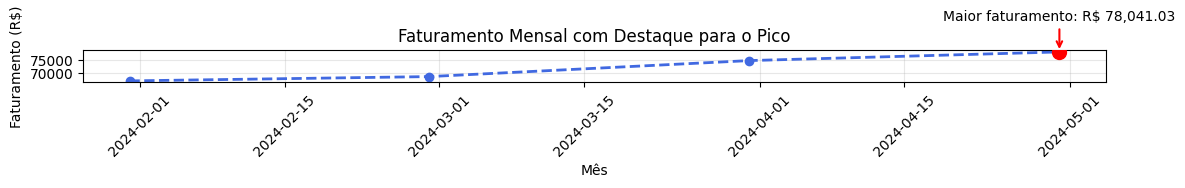

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue',
    linewidth=2
)

# Localizando o mês de maior faturamento
mes_pico = faturamento_mensal.idxmax()
valor_pico = faturamento_mensal.max()

# Destacando o pico
ax.scatter(
    mes_pico,
    valor_pico,
    color='red',
    s=100,
    zorder=5
)

# Anotação com seta
ax.annotate(
    f'Maior faturamento: R$ {valor_pico:,.2f}',
    xy=(mes_pico, valor_pico),
    xytext=(mes_pico, valor_pico * 1.15),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        linewidth=1.5
    ),
    ha='center'
)

ax.set_title('Faturamento Mensal com Destaque para o Pico')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Parte 3 — Matriz de intensidade  Tabela dinâmica com pivot_table

In [8]:
tabela_pivot = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum',
    fill_value=0
)

print(tabela_pivot)

estado             BA        MG        RJ        RS        SP
categoria                                                    
Automotivo    6992.96  16333.39  26783.38  10122.88  26727.57
Eletronicos  14211.94  13453.06   1154.47  13966.62   9372.80
Livros        4318.03  25667.11   9659.57  19302.59  23104.72
Roupas       26968.88   9876.74  11120.83   4809.04  14856.77


Renderizar o Heatmap com imshow()

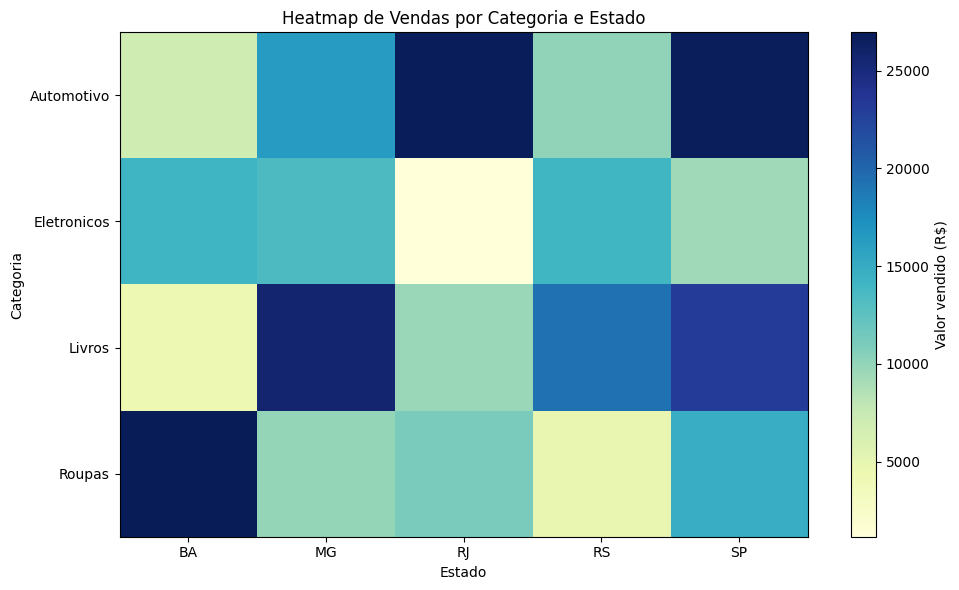

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

imagem = ax.imshow(
    tabela_pivot.values,
    cmap='YlGnBu',
    aspect='auto'
)

# Rótulos do eixo X: estados
ax.set_xticks(range(len(tabela_pivot.columns)))
ax.set_xticklabels(tabela_pivot.columns)

# Rótulos do eixo Y: categorias
ax.set_yticks(range(len(tabela_pivot.index)))
ax.set_yticklabels(tabela_pivot.index)

ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')
ax.set_title('Heatmap de Vendas por Categoria e Estado')

# Barra de cores
cbar = plt.colorbar(imagem, ax=ax)
cbar.set_label('Valor vendido (R$)')

plt.tight_layout()
plt.show()

Salvar o Heatmap em PNG com 300 DPI

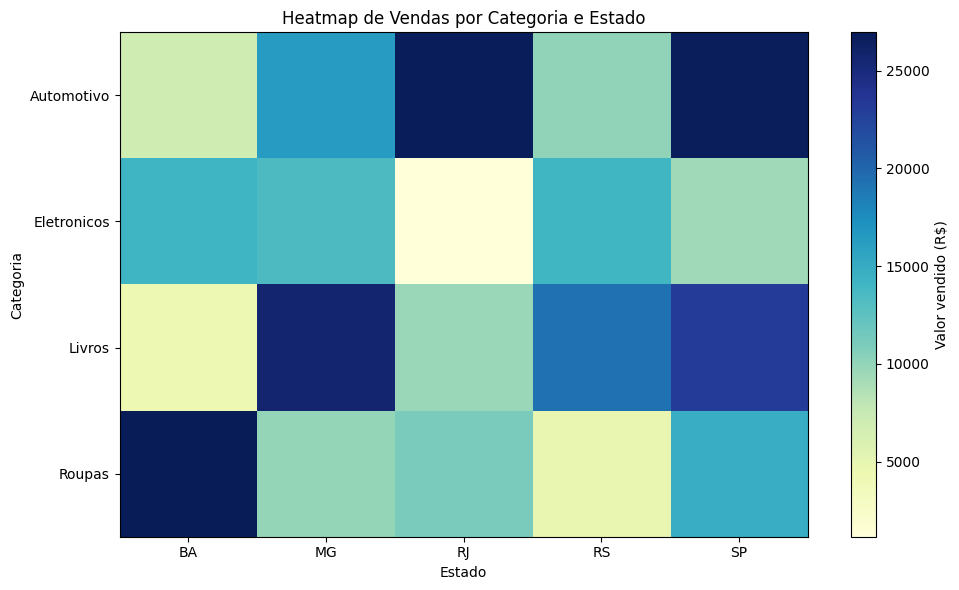

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

imagem = ax.imshow(
    tabela_pivot.values,
    cmap='YlGnBu',
    aspect='auto'
)

ax.set_xticks(range(len(tabela_pivot.columns)))
ax.set_xticklabels(tabela_pivot.columns)

ax.set_yticks(range(len(tabela_pivot.index)))
ax.set_yticklabels(tabela_pivot.index)

ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')
ax.set_title('Heatmap de Vendas por Categoria e Estado')

cbar = plt.colorbar(imagem, ax=ax)
cbar.set_label('Valor vendido (R$)')

plt.tight_layout()

# Salvando a figura
plt.savefig(
    'heatmap_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()